# Required Imports

In [188]:
%pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [189]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [190]:
# Suppress warnings and messages
warnings.filterwarnings('ignore')
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

# Import Data

The data I plan to use to train my models is the UC Irvine CDC Diabetes Health Indicators dataset. Below showcases the metadata, like the name of the dataset, repository url, and the data url. It also shows the different features that we'll be handling when training our models.

In [210]:
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
uci_df = pd.concat([cdc_diabetes_health_indicators.data.features, cdc_diabetes_health_indicators.data.targets], axis=1)
uci_df = uci_df.drop_duplicates()

# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

According to the feature information shown above, it's clear that most of the features are binary, with a few numeric, integer features. Furthermore, it also states that none of the features have any missing values. We will confirm this in the exploratory data analysis.

# Exploratory Data Analysis (EDA)

Below showcases an example of what the dataset looks like as well as the value counts for the target variable, `Diabetes_binary`.

In [211]:
uci_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [212]:
# Target variable distribution
uci_df['Diabetes_binary'].value_counts()

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64

According to the counts here, there seems to be an imbalance in target variable, an over-representation of those with no diabetes. This signifies that we probably will have to deal with this imbalance using a synthetic sampling method like SMOTE.

Before we perform the exploratory data analysis, we will check for missing and duplicate values in the dataset.

In [194]:
# Check for missing values
uci_df.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

In [195]:
# Check duplicate rows
uci_df.duplicated().sum()

0

Since there seems to be no missing values nor duplicated rows, we won't need to do any data preparation to handle these cases.

Below is a plot that visualizes all binary columns and calculates the diabetes risk for each feature. This is done by taking the difference between the mean rate between those who have diabetes and those who don't.

Text(0.5, 1.0, 'Increase in Diabetes Risk by Feature')

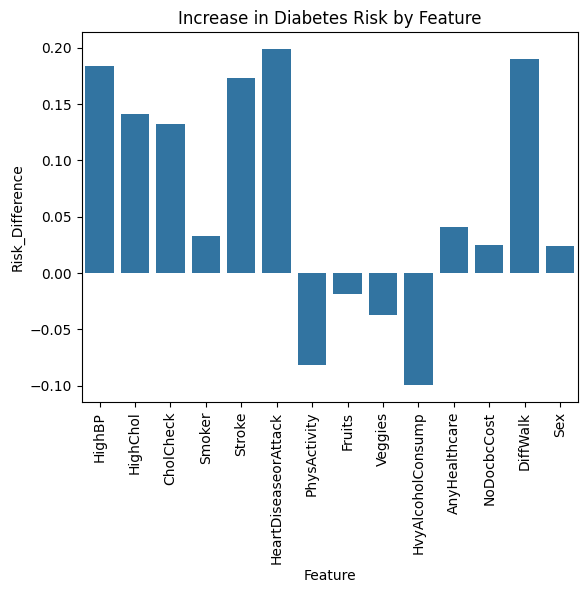

In [196]:
binary_cols = [row for row, type in zip(cdc_diabetes_health_indicators.variables.name, cdc_diabetes_health_indicators.variables.type) if type == 'Binary' and row != 'Diabetes_binary']

diffs = {
    col: uci_df.groupby(col)["Diabetes_binary"].mean().diff().iloc[-1]
    for col in binary_cols
}

plot_df = pd.Series(diffs).reset_index()
plot_df.columns = ["Feature","Risk_Difference"]

sns.barplot(data=plot_df, x="Feature", y="Risk_Difference")
plt.xticks(rotation=90)
plt.title("Increase in Diabetes Risk by Feature")

From the plot above, we can see that people with high blood pressure and high cholesterol both have around a 15-17% increased risk of getting diabetes. In terms of medical history and lifestyle, people who have had a stroke, heart disease, heart attack, and people who have difficulty walking all have around a 17-20% increased risk in getting diabetes. On the other hand, those who have participated in physical activity and those who don't consume heavy amounts of alcohol actually have around a 10% decreased risk in getting diabetes. This clearly shows that there are definitely some factors that contribute to the likelihood of an individual getting diabetes.

Below are the stacked bar charts for income, education, and general health features. For context, on the income feature scale, the higher the number, the higher the income, ranging from less than $10,000 a year to $75,000 or more a year. For education, the higher the number, the higher the education, ranging from never attended school / kindergarden to college graduate. For general health, 1 means the individual believes their general health is very healthy whilst 5 means they believe they are very unhealthy.

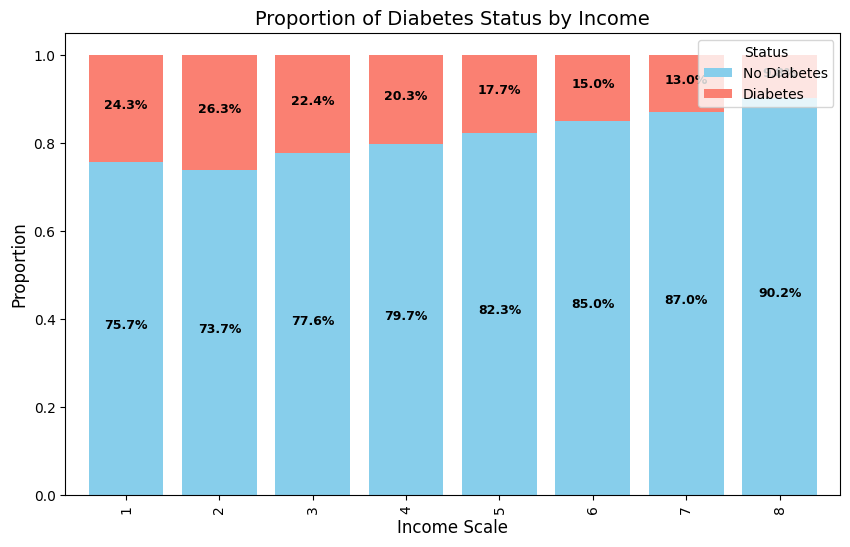

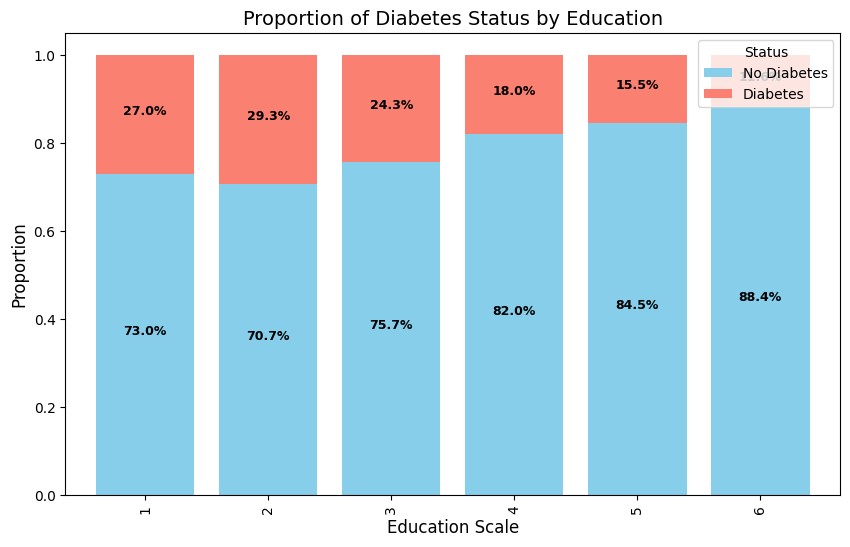

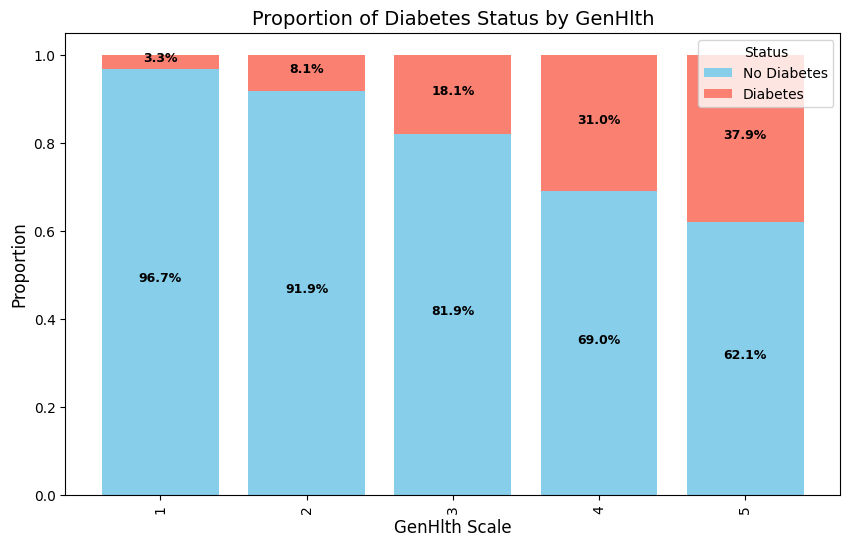

In [197]:
# Ordinal bar plots
ordinal_cols = ['Income', 'Education', 'GenHlth']
for col in ordinal_cols:
    cross_tab = pd.crosstab(uci_df[col], uci_df['Diabetes_binary'])
    
    cross_tab_prop = cross_tab.div(cross_tab.sum(1).astype(float), axis=0)
    
    ax = cross_tab_prop.plot(kind='bar', 
                             stacked=True, 
                             figsize=(10, 6), 
                             color=['skyblue', 'salmon'],
                             width=0.8)

    plt.title(f'Proportion of Diabetes Status by {col}', fontsize=14)
    plt.xlabel(f'{col} Scale', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.legend(title='Status', labels=['No Diabetes', 'Diabetes'], loc='upper right')
    
    for n, x in enumerate([*cross_tab_prop.index.values]):
        for (proportion, y_loc) in zip(cross_tab_prop.loc[x],
                                       cross_tab_prop.loc[x].cumsum()):
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{np.round(proportion * 100, 1)}%', 
                     color="black",
                     fontsize=9,
                     fontweight="bold",
                     ha="center")

    plt.show()

There are some clear trends when observing these plots. A larger proportion of those with a lower annual income seem to have diabetes. Similarly, those with less education also seem to have a larger proportion in which individuals have diabetes. This could be possibly due to the correlation between education and income. Individuals who have a lower income will more likely not have as much access to healthier foods, which are typically more expensive, as well as healthcare, which could allow people to monitor their health. For general health, as expected, there's a large proportion of people with diabetes who perceive their overall health to be poor, with 37.9% of participants who rated their general health as a 5 ended up having diabetes.

Next are features with wider numeric ranges, like physical health, mental health, and BMI. For these, I plotted them in kernel density estimate plots in order to see where most of the data lies.

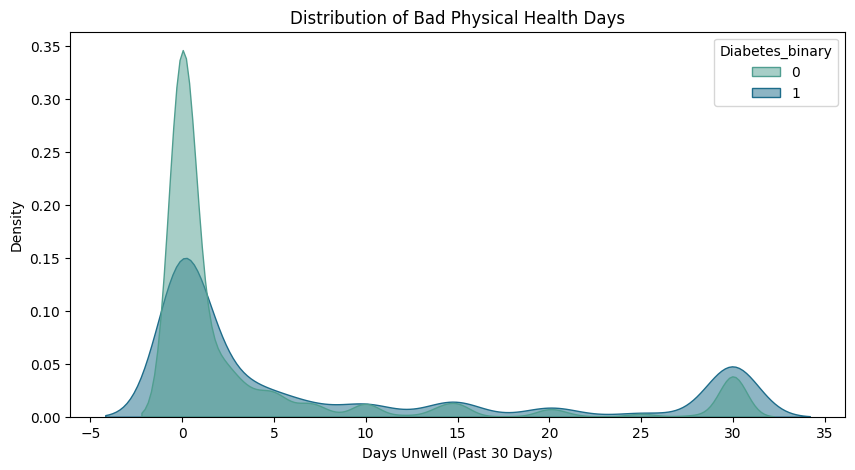

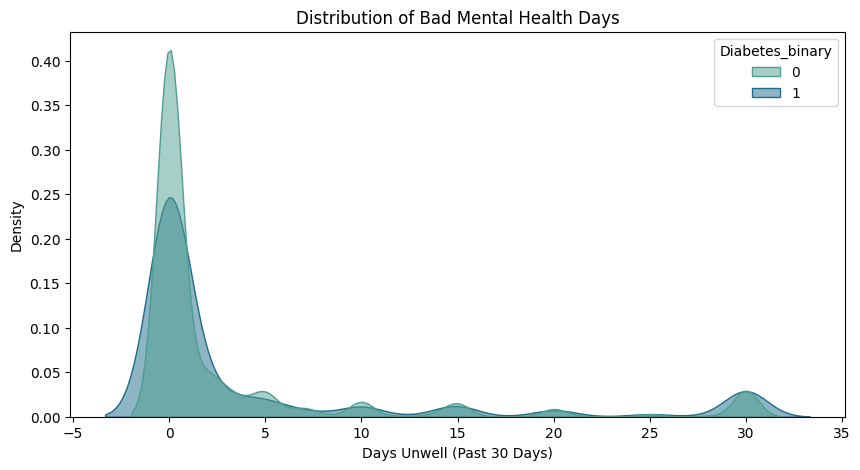

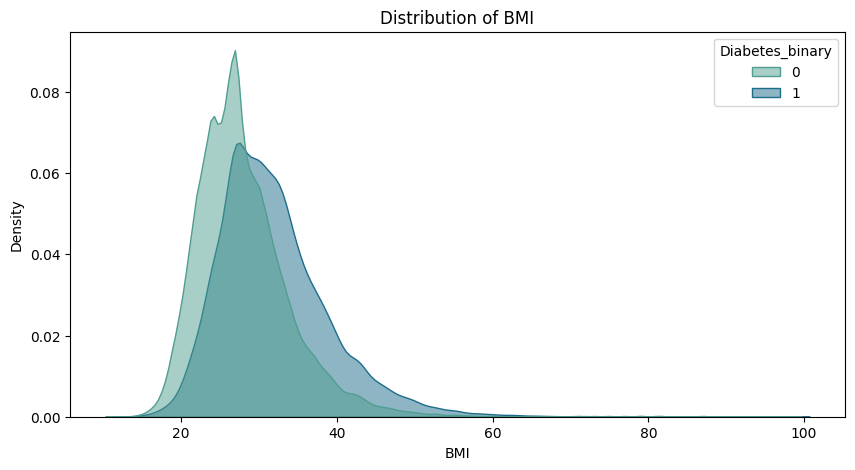

In [198]:
# Kernel Density Estimate (KDE) plots
plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='PhysHlth', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Bad Physical Health Days')
plt.xlabel('Days Unwell (Past 30 Days)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='MentHlth', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Bad Mental Health Days')
plt.xlabel('Days Unwell (Past 30 Days)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='BMI', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.show()

In terms of BMI, the graph plotting those who had diabetes is slightly shifted to the right compared to the graph plotting those who did not have diabetes. This shows that people with diabetes typically have higher BMIs than those who don't. When looking at the physical and mental health of participants, most people fall into the 0 (0 bad physical and mental days) or 30 (30 days of bad physical and mental days) category. In the plot, out of the people who had 0 bad physical and mental days, there were more people without diabetes compared to those who had it. The opposite is true when you look at those who had a full month's worth of bad physical and mental days.

Finally, plotting the age feature, shown below, signifies that the probability of getting diabetes increasing as people get older. There is a slight drop after the peak at the 11 group (particpants ages 70-74). This is likely because people who have diabetes statistically tend to not live as long.

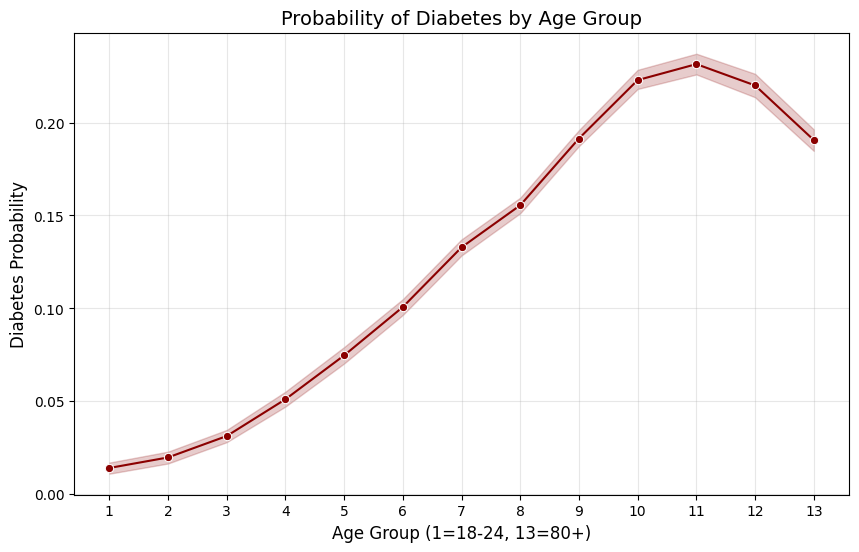

In [199]:
plt.figure(figsize=(10, 6))

# Plotting the mean of Diabetes_binary (which is the probability) for each Age bracket
sns.lineplot(x='Age', y='Diabetes_binary', data=uci_df, marker='o', color='darkred')

plt.title('Probability of Diabetes by Age Group', fontsize=14)
plt.xlabel('Age Group (1=18-24, 13=80+)', fontsize=12)
plt.ylabel('Diabetes Probability', fontsize=12)
plt.xticks(range(1, 14))
plt.grid(True, alpha=0.3)
plt.show()

To combine everything, below is a heatmap showcasing the correlation between all of the features.

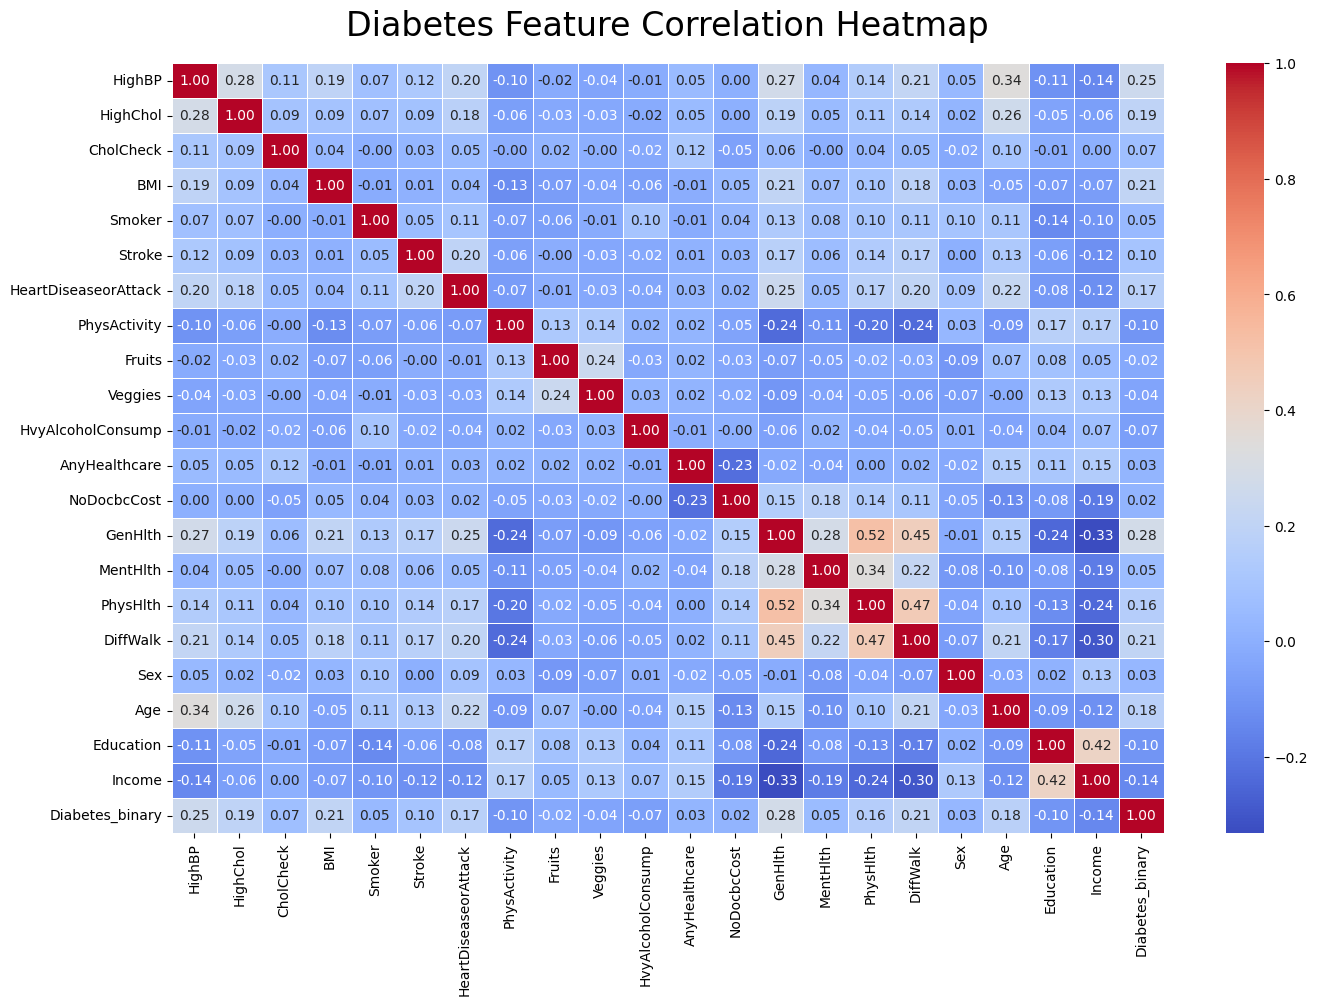

In [200]:
# Correlation heatmap
fig = plt.figure(figsize=(16, 10))
sns.heatmap(uci_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Diabetes Feature Correlation Heatmap", fontsize=24, pad=20)
plt.show()

This shows that there are a few highly correlated variables such as general health being highly correlated to both physical health and difficulty walking. There are some lifestyle features that were correlated like education and income. Soon, we will use these highly correlated variables as well as some other from domain knowledge to create some new features to add to the dataset.

Before adding these new features, to handle with the class imbalance, we'll apply SMOTE to create synthetic samples to balance the minority class, those who have diabetes.

In [227]:
# Apply SMOTE
uci_X = uci_df.drop('Diabetes_binary', axis=1)
uci_y = uci_df['Diabetes_binary']

smote = SMOTE(sampling_strategy='minority', random_state=42)

uci_X, uci_y = smote.fit_resample(uci_X, uci_y)

# Rebuild DataFrame
uci_df = pd.DataFrame(uci_X)
uci_df['Diabetes_binary'] = uci_y

Just to be safe, we'll check for missing and duplicate rows again.

In [229]:
# Check for missing values
uci_X.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [231]:
# Check for duplicate rows
uci_df.duplicated().sum()

81773

Since applying SMOTE seemed to create some duplicate rows, we're going to have to delete them.

In [232]:
uci_df = uci_df.drop_duplicates()

Once again, we will check the value counts for the target variable.

In [233]:
uci_df['Diabetes_binary'].value_counts()

Diabetes_binary
0    194377
1    112604
Name: count, dtype: int64

Although the target variable is not totally evened out, there is a much better balance between the two classes. Because of this, the models that will be trained in the future will be able to properly learn about those who have diabetes.

Now, we will perform EDA once again but with the SMOTE data to see if any distributions have changed.

Starting with the diabetes risk for binary features:

Text(0.5, 1.0, 'Increase in Diabetes Risk by Feature')

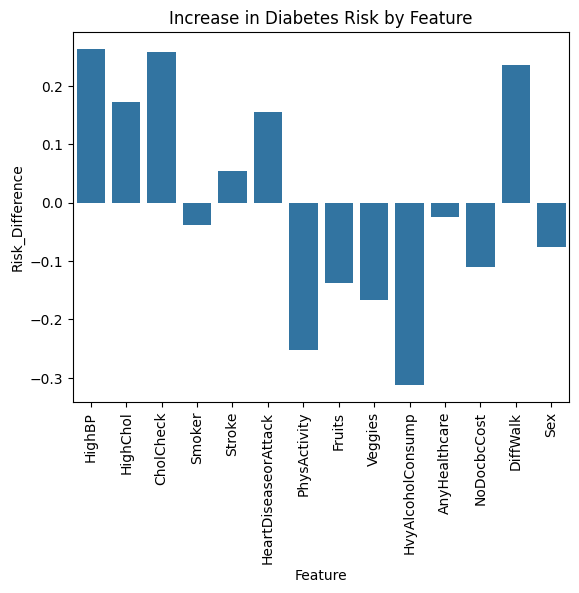

In [234]:
binary_cols = [row for row, type in zip(cdc_diabetes_health_indicators.variables.name, cdc_diabetes_health_indicators.variables.type) if type == 'Binary' and row != 'Diabetes_binary']

diffs = {
    col: uci_df.groupby(col)["Diabetes_binary"].mean().diff().iloc[-1]
    for col in binary_cols
}

plot_df = pd.Series(diffs).reset_index()
plot_df.columns = ["Feature","Risk_Difference"]

sns.barplot(data=plot_df, x="Feature", y="Risk_Difference")
plt.xticks(rotation=90)
plt.title("Increase in Diabetes Risk by Feature")

Comparing this to the previous, plot, it seems that applying SMOTE amplified features whose risk was above 0.05 and those below -0.05 risk. Features like `HighBP` and `CholCheck` increased to < 0.20 risk. On the other hand, for `PhysActivity` and `HvyAlcoholConsump`, the gap increased to -0.25 meaning those who participated in physical activity and those who did not consume heavy amounts of alcohol have a lower risk of diabetes.

Now for the ordinal bar plots to visualize income, education, and general health.

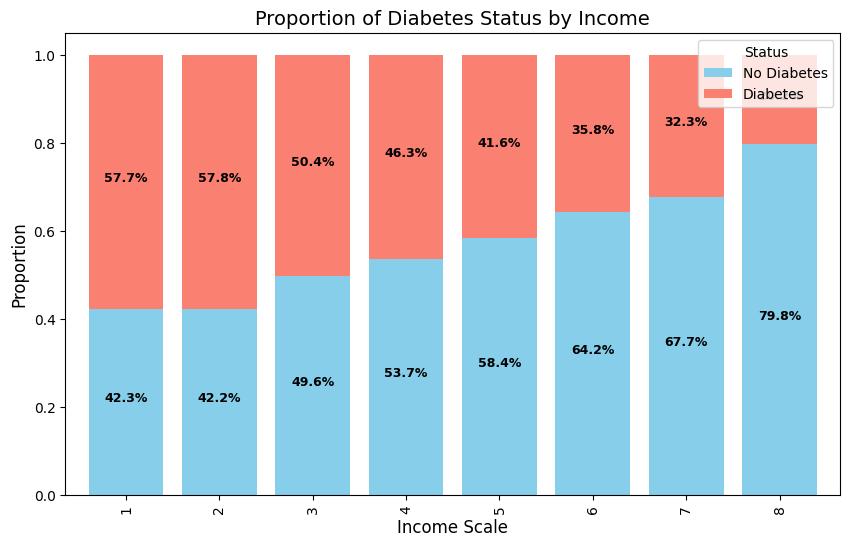

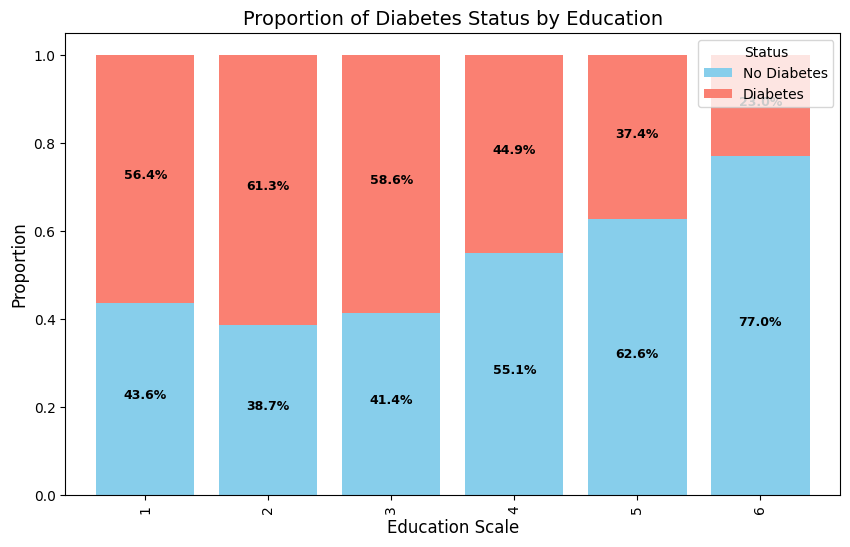

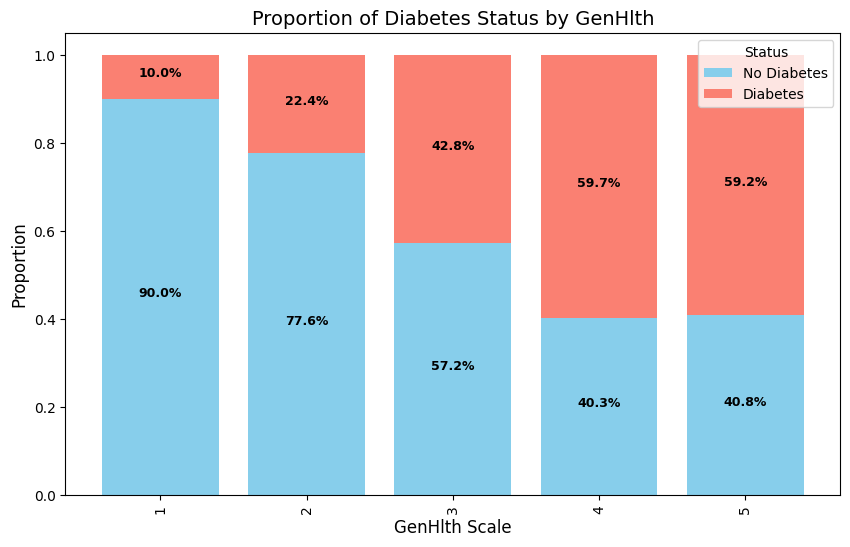

In [236]:
# Ordinal bar plots
ordinal_cols = ['Income', 'Education', 'GenHlth']
for col in ordinal_cols:
    cross_tab = pd.crosstab(uci_df[col], uci_df['Diabetes_binary'])
    
    cross_tab_prop = cross_tab.div(cross_tab.sum(1).astype(float), axis=0)
    
    ax = cross_tab_prop.plot(kind='bar', 
                             stacked=True, 
                             figsize=(10, 6), 
                             color=['skyblue', 'salmon'],
                             width=0.8)

    plt.title(f'Proportion of Diabetes Status by {col}', fontsize=14)
    plt.xlabel(f'{col} Scale', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.legend(title='Status', labels=['No Diabetes', 'Diabetes'], loc='upper right')
    
    for n, x in enumerate([*cross_tab_prop.index.values]):
        for (proportion, y_loc) in zip(cross_tab_prop.loc[x],
                                       cross_tab_prop.loc[x].cumsum()):
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{np.round(proportion * 100, 1)}%', 
                     color="black",
                     fontsize=9,
                     fontweight="bold",
                     ha="center")

    plt.show()

The trend is pretty much the same, with the number of diabetic participants increasing as you go up the general health scale (worse general health) whilst the number of diabetic participants decrease as you increase the income and education.

Now to plot the kernel density estimates:

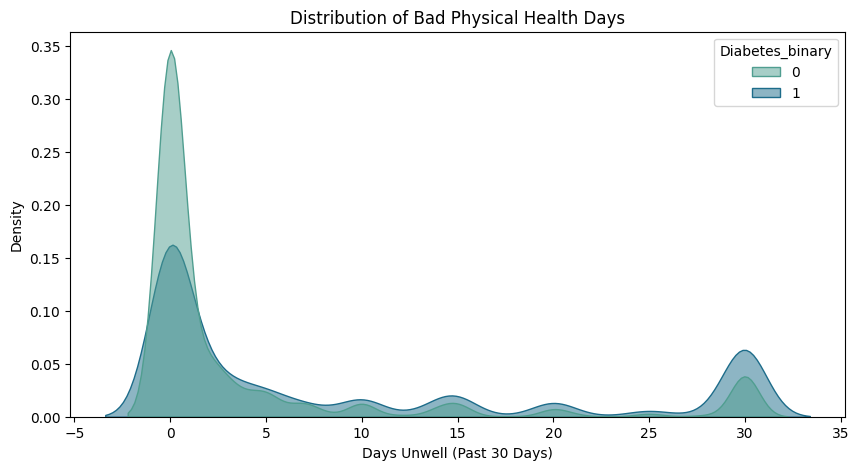

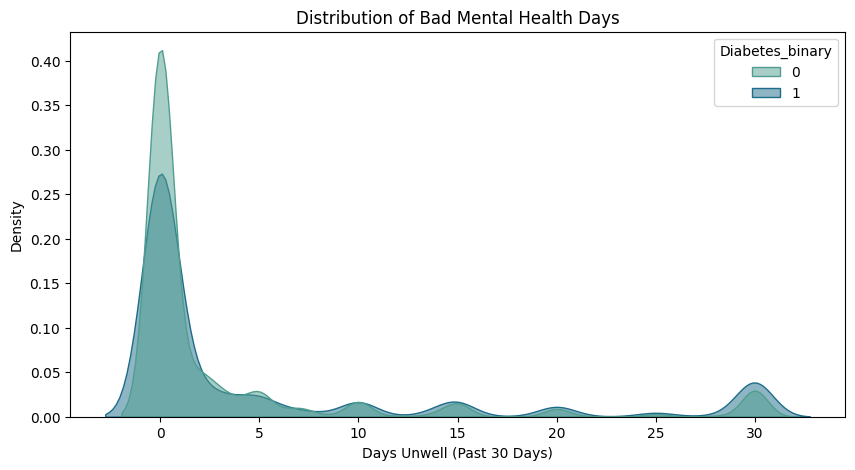

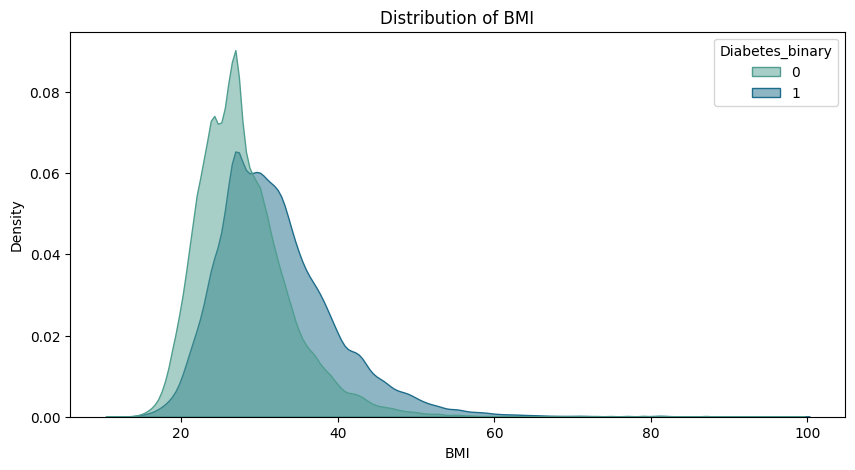

In [238]:
# Kernel Density Estimate (KDE) plots
plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='PhysHlth', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Bad Physical Health Days')
plt.xlabel('Days Unwell (Past 30 Days)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='MentHlth', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Bad Mental Health Days')
plt.xlabel('Days Unwell (Past 30 Days)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='BMI', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.show()

The KDE plots look pretty much identical in terms of trends between diabetic and non-diabetic participants. The main difference is just the increased density in diabetic samples.

Below is the plot for the age groups:

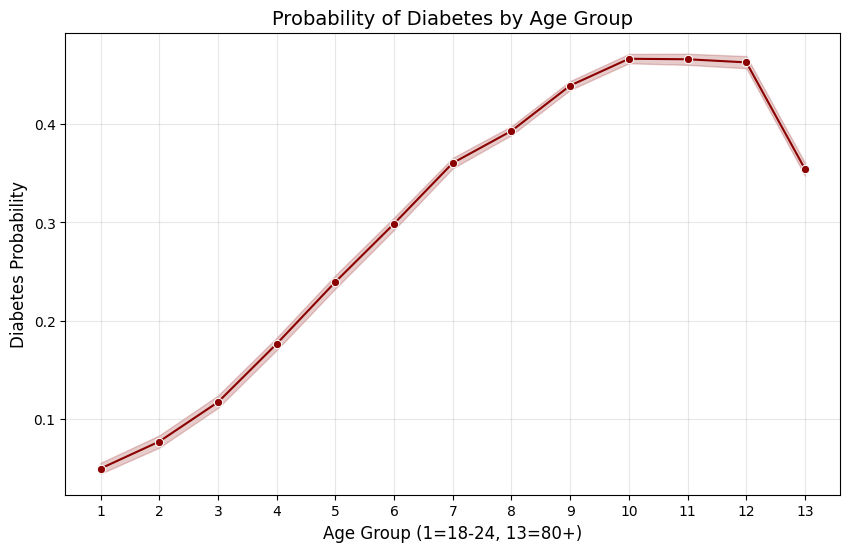

In [240]:
plt.figure(figsize=(10, 6))

# Plotting the mean of Diabetes_binary (which is the probability) for each Age bracket
sns.lineplot(x='Age', y='Diabetes_binary', data=uci_df, marker='o', color='darkred')

plt.title('Probability of Diabetes by Age Group', fontsize=14)
plt.xlabel('Age Group (1=18-24, 13=80+)', fontsize=12)
plt.ylabel('Diabetes Probability', fontsize=12)
plt.xticks(range(1, 14))
plt.grid(True, alpha=0.3)
plt.show()

The shape of this line graph is very similar to the original dataset aside from the consistent probability rate from age grouos 10-12. In addition, it seems that this graph is similar to the previous line graph but shifted upwards along the y-axis by around 0.05.

Finally, the updated correlation heatmap is shown below:

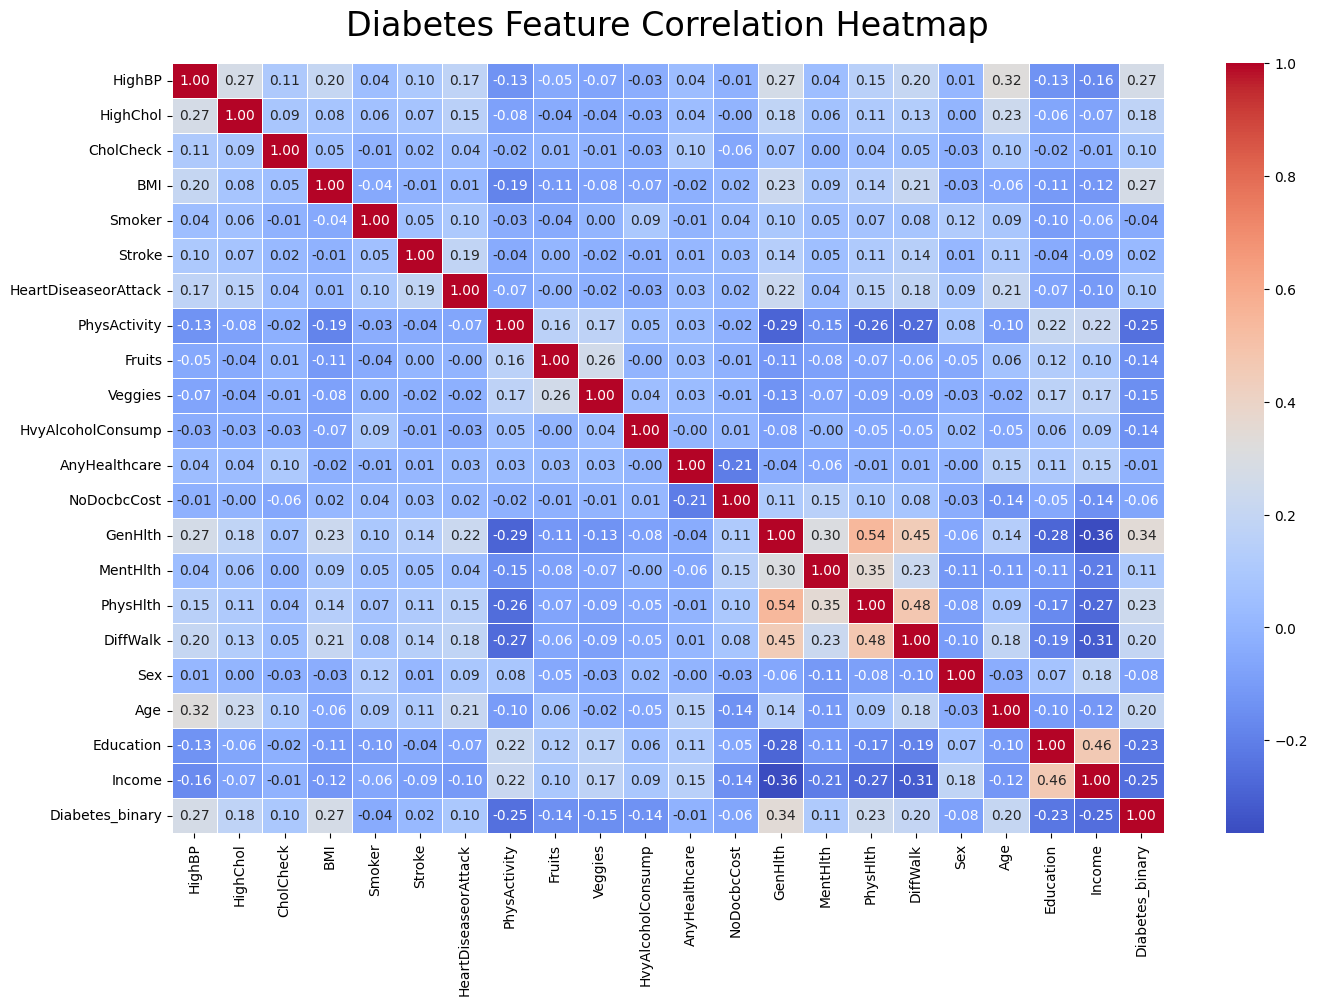

In [241]:
# Correlation heatmap
fig = plt.figure(figsize=(16, 10))
sns.heatmap(uci_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Diabetes Feature Correlation Heatmap", fontsize=24, pad=20)
plt.show()

This heatmap looks the same as the previous one. One noticeable difference, however, is that the correlation between `GenHlth` and `Diabetes_binary` has increased, meaning that we'll probably see that worse general health is a decent indicator for diabetes.

# Data Preparation and Feature Engineering

In addition to the original dataset, to assist with training, I feature engineered a few new features based on highly correlated features and also domain knowledge.

One highly correlated feature pair, as shown above, is `MentHlth` and `PhysHlth`, so I combined the two features to create a new feature representing today number of unhealthy days, `Total_Unhealthy_Days`. Another batch of correlated features was `GenHlth`, `DiffWalk`, and `PhysHlth`. These features are combined into a new feature called `Physical_Frailty`.

Based on current research and knowledge, those who have a high BMI and those who don't participate in physical activity will most likely develop diabetes in the future. These two features, `BMI` and `PhysActivity`, are combined to create a new feature, `BMI_Inactive`. Another one is `Smoker` and `PhysActivity`, a smoker in addition to lack of physical activity can combine to build insulin resistance while also weakening glucose management. These features combine to create `Lifestyle_Risk`.

In [248]:
# Total unhealthy days can be a strong indicator of overall health and diabetes risk
uci_df['Total_Unhealthy_Days'] = uci_df['MentHlth'] + uci_df['PhysHlth']

# A composite physical frailty score based on general health, difficulty walking, and physical health days
uci_df['Physical_Frailty'] = (((uci_df['GenHlth'] - 1) / 4) + uci_df['DiffWalk'] + (uci_df['PhysHlth'] / 30)) / 3

# Interaction between BMI and physical inactivity (not engaging in physical activity can exacerbate the effects of high BMI on diabetes risk)
uci_df['BMI_Inactive'] = uci_df['BMI'] * (1 - uci_df['PhysActivity'])

# A lifestyle risk score combining smoking, lack of healthcare access, and physical inactivity
uci_df['Lifestyle_Risk'] = (uci_df['Smoker'] + (1 - uci_df['PhysActivity']))

Below shows a graph of two of the new features, `Total_Unhealthy_Days` and `Lifestyle_Risk`, and how they affect an individual's risk of getting diabetes.

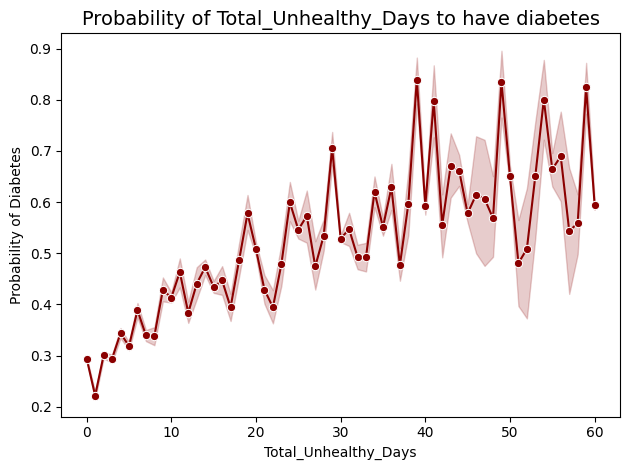

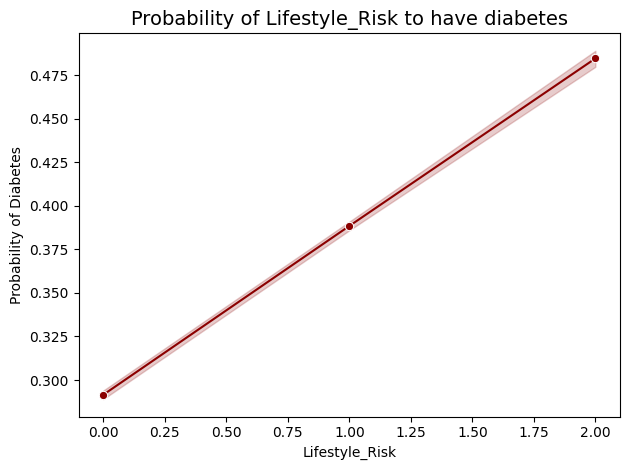

In [247]:
# Visualizing the relationship of these engineered features with diabetes probability
fig, axes = figsize=(18, 36)

columns = ['Total_Unhealthy_Days', 'Lifestyle_Risk']

for i, col in enumerate(columns):
    sns.lineplot(x=col, y='Diabetes_binary', data=uci_df, marker='o', color='darkred')
    plt.title(f'Probability of {col} to have diabetes', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Probability of Diabetes')

    plt.tight_layout()
    plt.show()

As seen in the plots above, when plotting `Total_Unhealthy_Days`, although the line is jagged, there is an overall positive trend when it comes to diabetes probability. As a person encounters more unhealthy days, mental and/or physical, their risk of diabetes seems to increase.

Simiarly, with `Lifestyle_Risk`, this trend also appears. This plot represents more of a linear trend, if a person participates in both smoking and lack of physical activity, their risk of diabetes increases.

Now, to show the impact of `BMI_Inactive`, we plotted the `BMI` column against `Diabetes_binary` for each value of `PhysActivity`.

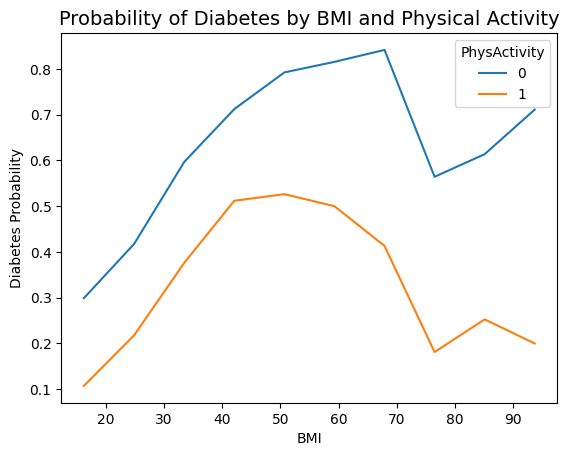

In [250]:
BMI_bin_df = uci_df.copy()
BMI_bin_df["BMI_bin"] = pd.cut(
    BMI_bin_df["BMI"],
    bins=10
)

line_data = (
    BMI_bin_df
    .groupby(["BMI_bin","PhysActivity"])["Diabetes_binary"]
    .mean()
    .reset_index()
)

line_data["bin_center"] = line_data["BMI_bin"].apply(lambda x: x.mid)

sns.lineplot(
    data=line_data,
    x="bin_center",
    y="Diabetes_binary",
    hue="PhysActivity"
)
plt.title('Probability of Diabetes by BMI and Physical Activity', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Diabetes Probability')
plt.show()

There seems to be a significant gap in the risk of getting diabetes between those who do physical activity and those who don't. The gap starts to increase as BMI increases, indicating that those who have a high BMI and those who don't do any physical activity have a significantly higher risk compared to those who do physical activity.

Finally, below is the plot of `Physical_Frailty`.

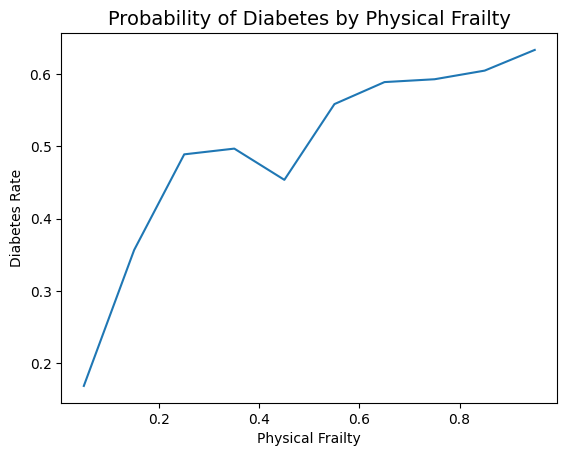

In [251]:
frailty = (
    uci_df
    .groupby(pd.cut(uci_df["Physical_Frailty"], bins=10))
    ["Diabetes_binary"]
    .mean()
    .reset_index()
)

frailty["mid"] = frailty["Physical_Frailty"].apply(lambda x: x.mid)

plt.plot(frailty["mid"], frailty["Diabetes_binary"])
plt.title('Probability of Diabetes by Physical Frailty', fontsize=14)
plt.xlabel("Physical Frailty")
plt.ylabel("Diabetes Rate")
plt.show()

As an individual's physical frailty increases, the rate of which diabetes can occur in people increases to over around 60%.

Now that all the features are in place, we apply a `StandardScalar` to apply standardization to standardize the features like `BMI`, `GenHlth`, and `PhysHlth` that are at a higher and wider range than the binary features. This is to prevent any bias towards those features in future model training with `LogisticRegression`, `KNN`, and `MLP` models.

In addition, we create a train-test split of 80:20. It should be a good enough size for models to train and learn.

In [253]:
# Standardize features for models sensitive to feature scaling
scaler = StandardScaler()
uci_X_scaled = scaler.fit_transform(uci_X)

In [254]:
uci_X_train, uci_X_test, uci_y_train, uci_y_test = train_test_split(uci_X_scaled, uci_y, test_size=0.2, stratify=uci_y, random_state=42)

# Baseline Model

For the baseline model, we train and fit a basic `LogisticRegression` model and output the cross-validation scores as well as the classification report and the confusion matrix.

In [255]:
lr = LogisticRegression()
lr.fit(uci_X_train, uci_y_train)

scores = cross_val_score(lr, uci_X_train, uci_y_train, cv=5, scoring="roc_auc")
print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.8040777331277489


In [256]:
lr_y_pred = lr.predict(uci_X_test)
print("Logistic Regression Classification Report:")
print(classification_report(uci_y_test, lr_y_pred))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(uci_y_test, lr_y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     38876
           1       0.72      0.74      0.73     38875

    accuracy                           0.73     77751
   macro avg       0.73      0.73      0.73     77751
weighted avg       0.73      0.73      0.73     77751

Logistic Regression Confusion Matrix:
[[27504 11372]
 [ 9988 28887]]


Based on the scores above, this seems like a good start if you're looking solely on the cross-validation score. But after analyzing the reports, it reveals that this model still misses a decent amount of diabetic cases, missing around ~25.6% of cases. Although it seems like a low number, this is still quite poor performance since it's missing over a quarter of cases.

Although not as urgent, this model still misses ~29.3% of non-diabetic cases, incorrectly predicting a participant had diabetes when they actually didn't.

When training and fitting models, the main goal is to minimize the amount of false negatives while also hoping to minimize false positives as well to ensure highest accuracy.